### 栅格数据读写

In [17]:
import rasterio as rio
import matplotlib.pyplot as plt 


In [14]:
path_data = 'data/rsimg/s2_20251206.tif'


In [16]:
rsimg = rio.open(path_data)
rsimg_arr = rsimg.read().transpose(1, 2, 0)
print(type(rsimg))
print(rsimg_arr.shape)


<class 'rasterio.io.DatasetReader'>
(2406, 1406, 6)


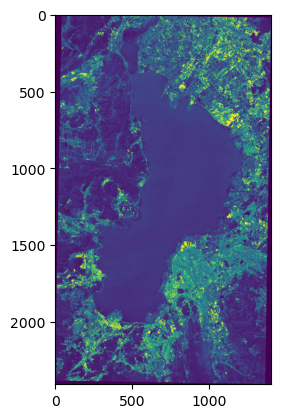

In [22]:
plt.imshow(rsimg_arr[:,:,0], vmax=2000, vmin=0) 


In [4]:
## 查看影像尺寸
print(rsimg.width)
print(rsimg.height)
print(rsimg.count)
## 查看坐标系统  
print(rsimg.crs)

1406
2406
6
EPSG:32648


In [ ]:
## 查看转换参数，含义为（x方向分辨率，x方向旋转参数，左上角x坐标，y方向旋转参数，y方向分辨率，左上角y坐标）
rsimg.transform    


Affine(20.0, 0.0, 251920.0,
       0.0, -20.0, 2770520.0)

In [6]:
print(rsimg.bounds)
print(rsimg.driver)


BoundingBox(left=251920.0, bottom=2722400.0, right=280040.0, top=2770520.0)
GTiff


In [7]:
## 查看主要信息，包括尺寸、坐标系等
rsimg.meta


{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 1406,
 'height': 2406,
 'count': 6,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32648"]]'),
 'transform': Affine(20.0, 0.0, 251920.0,
        0.0, -20.0, 2770520.0)}

#### 提取并写出波段

In [8]:
band1 = rsimg.read(4)
print(type(band1))
band1.shape
# bands = rsimg.read()
# # type(bands)
# bands.shape


<class 'numpy.ndarray'>


(2406, 1406)

In [9]:
#### 栅格数据写出(写出某个波段)
### 参数准备：driver, height, width, count, dtype, crs, transform
driver = 'GTiff'
height = band1.shape[0]
width = band1.shape[1]
count = 1
crs = rsimg.crs
dtype = band1.dtype
transform = rsimg.transform


In [10]:
path_band1 = 'data/rsimg/nir_band.tif'
with rio.open(path_band1, 'w', 
                driver=driver, 
                height=height,
                width=width,
                count=count,
                dtype=dtype,
                crs=crs,
                transform=transform) as dst:
  dst.write(band1, 1)   ## the number 1 is the number of bands.


